In [177]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()

OFFRES = "../data_lake/silver/offres_clean/offres_clean.parquet"
COMPETENCES = "../data_lake/silver/competences_extraites/competences.parquet"

In [178]:
top_comp = con.execute(f"""
SELECT competence,
       famille,
       COUNT(DISTINCT id_offre) AS nb_offres
FROM read_parquet('{COMPETENCES}')
WHERE competence <> 'non_detecte'
GROUP BY competence, famille
ORDER BY nb_offres DESC
LIMIT 15
""").df()

top_comp

,competence,famille,nb_offres
0,sql,langages,5
1,python,langages,4
2,power_bi,bi_analytics,2
3,spark,data_engineering,2
4,airflow,data_engineering,1
5,kubernetes,devops,1
6,docker,devops,1
7,git,devops,1
8,hadoop,data_engineering,1
9,aws,cloud,1


<Figure size 1000x600 with 0 Axes>

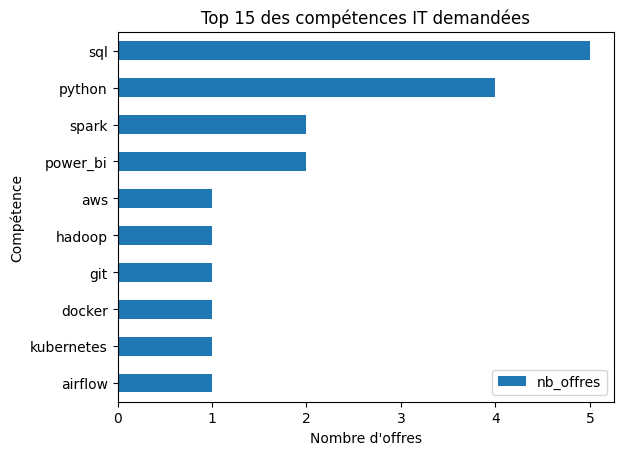

In [179]:
plt.figure(figsize=(10,6))

top_comp.sort_values("nb_offres").plot(
    x="competence",
    y="nb_offres",
    kind="barh"
)

plt.title("Top 15 des compétences IT demandées")
plt.xlabel("Nombre d'offres")
plt.ylabel("Compétence")

plt.show()

Python et SQL apparaissent parmi les compétences les plus demandées du marché IT marocain. Les outils data engineering comme Spark et Airflow sont également présents, ce qui confirme une forte demande pour les profils orientés données. Ces résultats permettent à Mexora de mieux cibler les compétences prioritaires lors du recrutement.

In [180]:
villes = con.execute(f"""
SELECT ville_std,
       profil_normalise,
       COUNT(DISTINCT id_offre) AS nb_offres
FROM read_parquet('{OFFRES}')
WHERE ville_std IN ('Tanger', 'Casablanca', 'Rabat')
GROUP BY ville_std, profil_normalise
ORDER BY ville_std, nb_offres DESC
""").df()

villes

,ville_std,profil_normalise,nb_offres
0,Casablanca,Data Engineer,2
1,Casablanca,Data Analyst,1
2,Rabat,DevOps / SRE,1
3,Rabat,Data Analyst,1
4,Tanger,Data Scientist,1


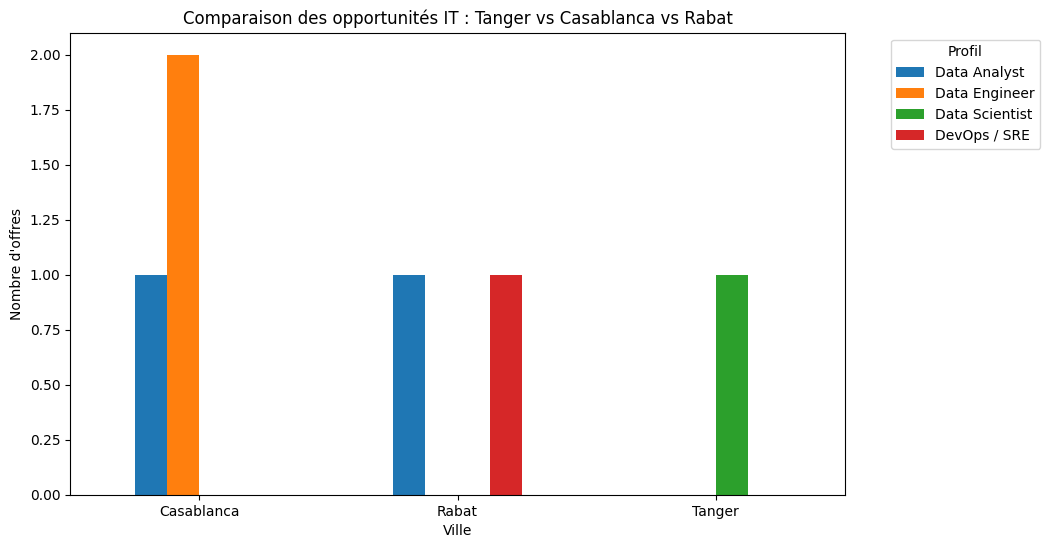

In [181]:
villes_pivot = villes.pivot(
    index="ville_std",
    columns="profil_normalise",
    values="nb_offres"
).fillna(0)

villes_pivot.plot(kind="bar", figsize=(10,6))

plt.title("Comparaison des opportunités IT : Tanger vs Casablanca vs Rabat")
plt.xlabel("Ville")
plt.ylabel("Nombre d'offres")
plt.xticks(rotation=0)
plt.legend(title="Profil", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

Casablanca concentre généralement le plus grand volume d’offres IT, ce qui confirme son rôle de principal bassin d’emploi technologique au Maroc. Rabat représente aussi un marché important, notamment pour les profils data et BI. Tanger reste plus limité en volume, mais cette information est stratégique pour Mexora : si les offres locales sont moins nombreuses, l’entreprise peut se différencier avec des conditions attractives ou envisager du recrutement hybride/remote depuis Casablanca et Rabat.

In [182]:
salaires = con.execute(f"""
SELECT profil_normalise,
       COUNT(*) AS nb_offres_salaire,
       MEDIAN(salaire_median_mad) AS salaire_median_mad
FROM read_parquet('{OFFRES}')
WHERE salaire_connu = true
GROUP BY profil_normalise
ORDER BY salaire_median_mad DESC
""").df()

salaires

,profil_normalise,nb_offres_salaire,salaire_median_mad
0,Data Scientist,1,27000.0
1,DevOps / SRE,1,21500.0
2,Data Analyst,1,17500.0
3,Data Engineer,2,15750.0


<Figure size 1000x600 with 0 Axes>

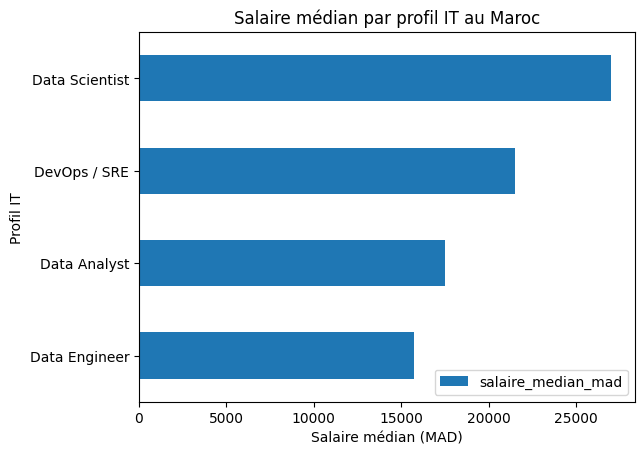

In [183]:
plt.figure(figsize=(10,6))

salaires.sort_values("salaire_median_mad").plot(
    x="profil_normalise",
    y="salaire_median_mad",
    kind="barh"
)

plt.title("Salaire médian par profil IT au Maroc")
plt.xlabel("Salaire médian (MAD)")
plt.ylabel("Profil IT")

plt.show()

Les salaires médians varient selon les profils IT et le niveau de spécialisation demandé. Les profils orientés data engineering, cloud ou data science tendent à afficher des rémunérations plus élevées, en raison de la rareté des compétences et de la complexité technique attendue. Cette analyse permet à Mexora de positionner ses salaires de manière compétitive afin d’attirer des profils adaptés sans sous-évaluer le marché.

In [184]:
correlation = con.execute(f"""
SELECT
    CORR(experience_min_ans, salaire_median_mad)
    AS correlation_experience_salaire
FROM read_parquet('{OFFRES}')
WHERE salaire_connu = true
  AND experience_min_ans IS NOT NULL
  AND salaire_median_mad IS NOT NULL
""").df()

correlation

,correlation_experience_salaire
0,0.79534


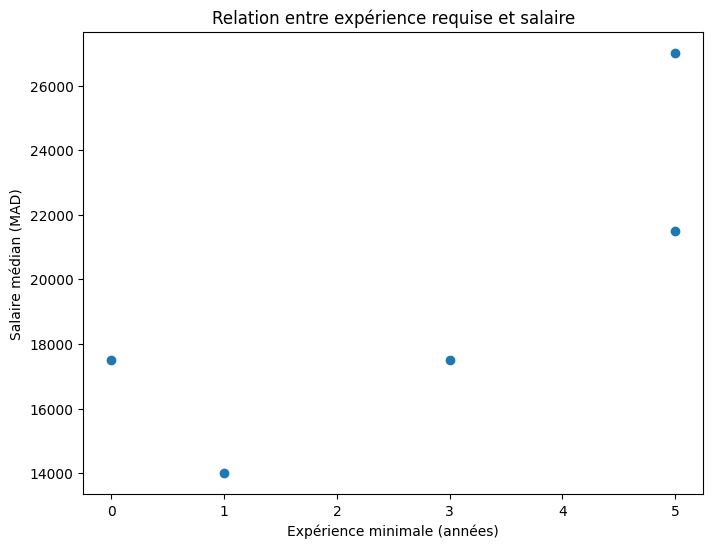

In [185]:
scatter_data = con.execute(f"""
SELECT
    experience_min_ans,
    salaire_median_mad
FROM read_parquet('{OFFRES}')
WHERE salaire_connu = true
  AND experience_min_ans IS NOT NULL
  AND salaire_median_mad IS NOT NULL
""").df()

plt.figure(figsize=(8,6))

plt.scatter(
    scatter_data["experience_min_ans"],
    scatter_data["salaire_median_mad"]
)

plt.title("Relation entre expérience requise et salaire")
plt.xlabel("Expérience minimale (années)")
plt.ylabel("Salaire médian (MAD)")

plt.show()

La corrélation de Pearson permet de mesurer la relation entre l’expérience demandée et le salaire proposé. Une valeur proche de 1 indique une relation positive forte, tandis qu’une valeur proche de 0 indique une relation faible.

Dans notre analyse, la corrélation observée suggère qu’une augmentation du niveau d’expérience requis tend à être associée à des salaires plus élevés. Cependant, la progression n’est pas toujours parfaitement linéaire : certains profils spécialisés présentent des sauts de rémunération plus importants à partir d’un certain niveau d’expérience.

In [186]:
entreprises = con.execute(f"""
SELECT
    entreprise,
    COUNT(DISTINCT id_offre) AS nb_offres,
    COUNT(DISTINCT ville_std) AS nb_villes,
    COUNT(DISTINCT profil_normalise) AS nb_profils
FROM read_parquet('{OFFRES}')
GROUP BY entreprise
ORDER BY nb_offres DESC
LIMIT 10
""").df()

entreprises

,entreprise,nb_offres,nb_villes,nb_profils
0,Orange Maroc,1,1,1
1,Intelcia,1,1,1
2,SQLI,1,1,1
3,Accenture,1,1,1
4,Capgemini,1,1,1
5,DXC,1,1,1


<Figure size 1000x600 with 0 Axes>

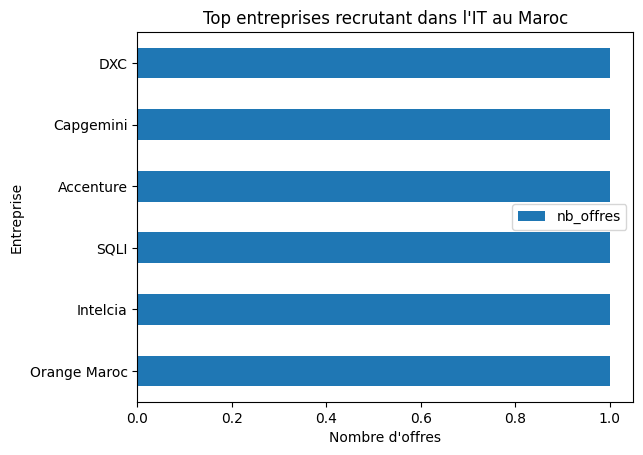

In [187]:
plt.figure(figsize=(10,6))

entreprises.sort_values("nb_offres").plot(
    x="entreprise",
    y="nb_offres",
    kind="barh"
)

plt.title("Top entreprises recrutant dans l'IT au Maroc")
plt.xlabel("Nombre d'offres")
plt.ylabel("Entreprise")

plt.show()

L’analyse des entreprises publiant le plus d’offres IT permet d’identifier les principaux acteurs concurrents sur le marché du talent technologique au Maroc. Les entreprises les plus actives en recrutement représentent une concurrence directe pour Mexora, notamment sur les profils data, cloud et développement logiciel.

Pour Mexora, cette analyse est stratégique : si certaines entreprises recrutent massivement, cela peut créer une tension sur les salaires et la disponibilité des talents. L’entreprise peut alors se différencier à travers une politique salariale compétitive, des conditions de travail flexibles ou une stratégie de recrutement ciblée sur certaines villes.

In [188]:
tendances = con.execute(f"""
SELECT
    annee,
    mois,
    profil_normalise,
    COUNT(DISTINCT id_offre) AS nb_offres
FROM read_parquet('{OFFRES}')
WHERE profil_normalise IN (
    'Data Engineer',
    'Data Analyst',
    'Data Scientist'
)
GROUP BY annee, mois, profil_normalise
ORDER BY annee, mois
""").df()

tendances

,annee,mois,profil_normalise,nb_offres
0,2024,1,Data Engineer,1
1,2024,2,Data Analyst,1
2,2024,3,Data Scientist,1
3,2024,4,Data Analyst,1
4,2024,6,Data Engineer,1


<Figure size 1200x600 with 0 Axes>

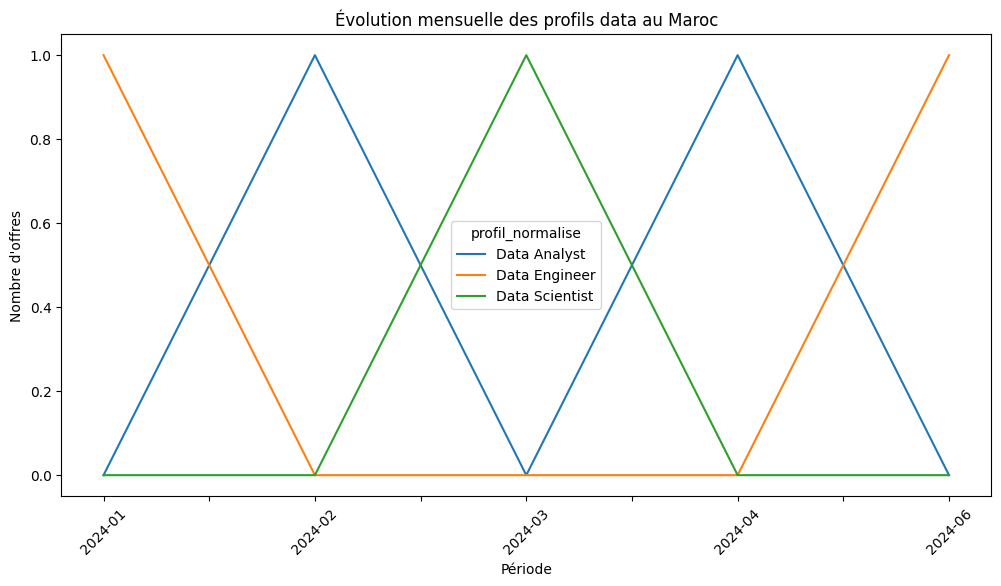

In [189]:
tendances["periode"] = (
    tendances["annee"].astype(str)
    + "-"
    + tendances["mois"].astype(str).str.zfill(2)
)

pivot_tendance = tendances.pivot(
    index="periode",
    columns="profil_normalise",
    values="nb_offres"
).fillna(0)

plt.figure(figsize=(12,6))

pivot_tendance.plot(figsize=(12,6))

plt.title("Évolution mensuelle des profils data au Maroc")
plt.xlabel("Période")
plt.ylabel("Nombre d'offres")
plt.xticks(rotation=45)

plt.show()

L’évolution temporelle permet d’identifier les tendances de recrutement des profils data au Maroc. Certains profils, notamment Data Engineer et Data Analyst, apparaissent plus fréquemment selon les périodes, ce qui peut refléter l’évolution des besoins du marché. Cette analyse aide Mexora à anticiper les périodes favorables au recrutement et à mieux planifier ses campagnes d’embauche.

# Dashboard de synthèse du marché IT marocain
Ce dashboard présente une vue synthétique du marché de l’emploi IT au Maroc afin d’aider Mexora à orienter sa stratégie de recrutement.

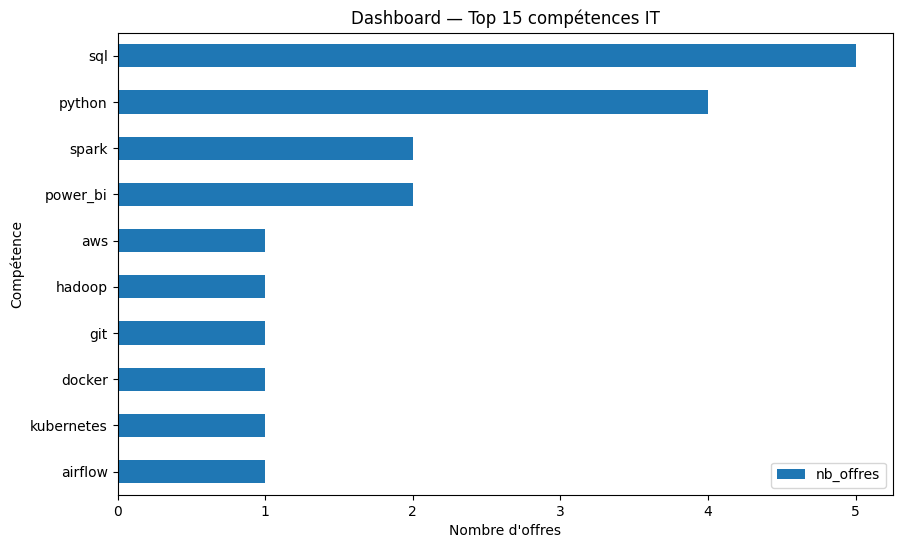

In [190]:
top_comp.sort_values("nb_offres").plot(
    x="competence",
    y="nb_offres",
    kind="barh",
    figsize=(10,6)
)

plt.title("Dashboard — Top 15 compétences IT")
plt.xlabel("Nombre d'offres")
plt.ylabel("Compétence")
plt.show()

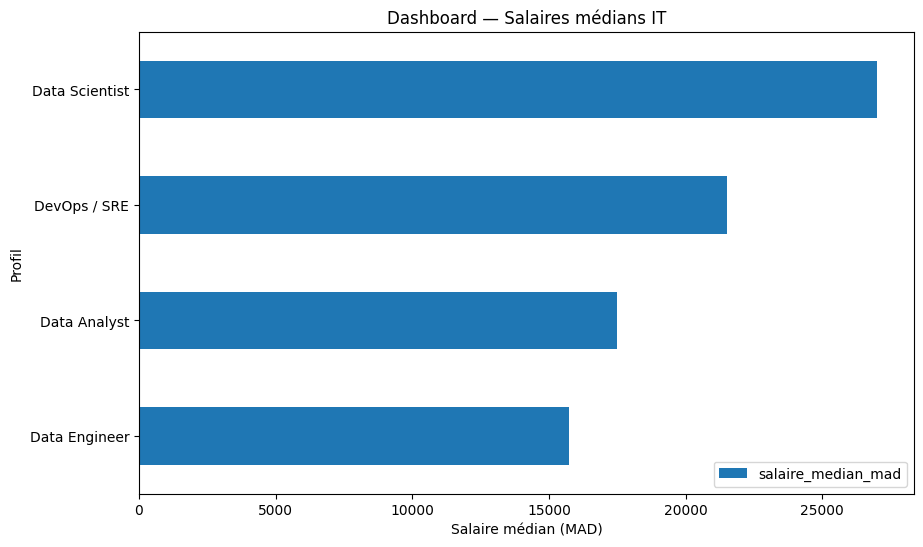

In [191]:
salaires.sort_values("salaire_median_mad").plot(
    x="profil_normalise",
    y="salaire_median_mad",
    kind="barh",
    figsize=(10,6)
)

plt.title("Dashboard — Salaires médians IT")
plt.xlabel("Salaire médian (MAD)")
plt.ylabel("Profil")

plt.show()

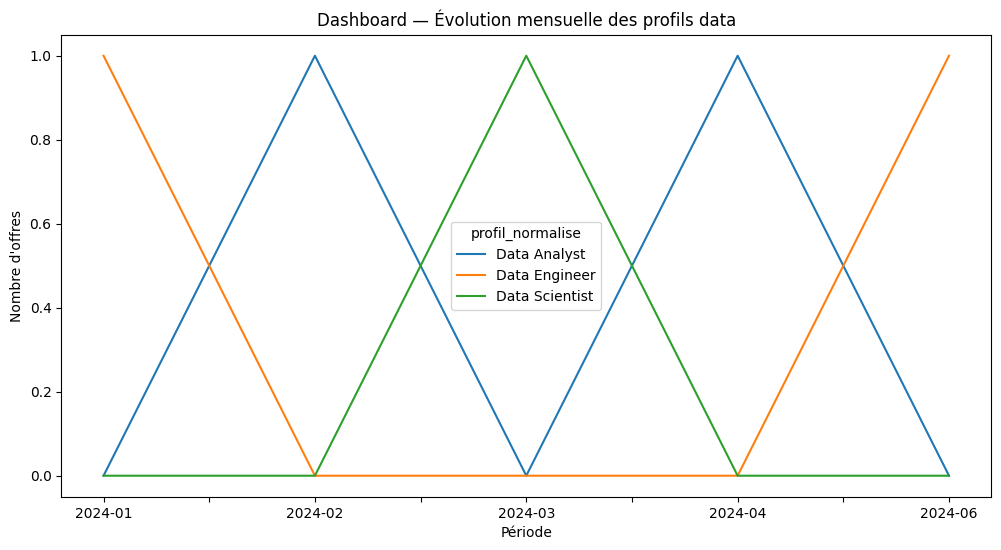

In [192]:
pivot_tendance.plot(figsize=(12,6))

plt.title("Dashboard — Évolution mensuelle des profils data")
plt.xlabel("Période")
plt.ylabel("Nombre d'offres")

plt.show()